In [1]:
import pandas as pd
import torch
from transformers import BertTokenizer, BertForTokenClassification, AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import numpy as np

In [2]:
import pandas as pd

# Load labeled dataset
df_labeled = pd.read_csv('C:/Users/Devanand J/Desktop/Final/SemEval.csv')
import pandas as pd

texts = df_labeled['comments'].tolist()
aspect_terms = df_labeled['aspectTerms'].tolist()

print(f"Sample texts: {texts[:3]}")
print(f"Sample aspect_terms: {aspect_terms[:3]}")

Sample texts: ['But the staff was so horrible to us.', "To be completely fair, the only redeeming factor was the food, which was above average, but couldn't make up for all the other deficiencies of Teodora.", "The food is uniformly exceptional, with a very capable kitchen which will proudly whip up whatever you feel like eating, whether it's on the menu or not."]
Sample aspect_terms: ["[{'term': 'staff', 'polarity': 'negative'}]", "[{'term': 'food', 'polarity': 'positive'}]", "[{'term': 'food', 'polarity': 'positive'}, {'term': 'kitchen', 'polarity': 'positive'}, {'term': 'menu', 'polarity': 'neutral'}]"]


In [3]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


C:\Users\Devanand J\anaconda3\envs\gpt_cuda118\Lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
label_map = {
    'O': 0,
    'B-POS': 1,
    'I-POS': 2,
    'B-NEG': 3,
    'I-NEG': 4,
    'B-NEU': 5,
    'I-NEU': 6
}

def encode_labels(texts, aspect_info_list):
    all_labels = []
    for i, text in enumerate(texts):
        tokenized_text = tokenizer.tokenize(text)
        labels = ['O'] * len(tokenized_text)
        
        aspect_info = eval(aspect_info_list[i])
        
        for aspect in aspect_info:
            aspect_term = aspect['term']
            aspect_polarity = aspect['polarity']
            aspect_tokens = tokenizer.tokenize(aspect_term)

            # Find the start index of the aspect term in tokens
            start_idx = -1
            for j in range(len(tokenized_text) - len(aspect_tokens) + 1):
                if tokenized_text[j:j+len(aspect_tokens)] == aspect_tokens:
                    start_idx = j
                    break

# Assigning labels based on aspect polarity
            if start_idx != -1:
                polarity_tag = 'POS' if aspect_polarity == 'positive' else 'NEG' if aspect_polarity == 'negative' else 'NEU'
                labels[start_idx] = f'B-{polarity_tag}'
                for k in range(1, len(aspect_tokens)):
                    labels[start_idx + k] = f'I-{polarity_tag}'
        
        all_labels.append([label_map[label] for label in labels])
    return all_labels

labels = encode_labels(texts, aspect_terms)

# Printing the first few tokenized texts and their labels
for i in range(3):
    print(f"Text {i}: {texts[i]}")
    print(f"Tokenized Text {i}: {tokenizer.tokenize(texts[i])}")
    print(f"Labels {i}: {labels[i]}")


Text 0: But the staff was so horrible to us.
Tokenized Text 0: ['but', 'the', 'staff', 'was', 'so', 'horrible', 'to', 'us', '.']
Labels 0: [0, 0, 3, 0, 0, 0, 0, 0, 0]
Text 1: To be completely fair, the only redeeming factor was the food, which was above average, but couldn't make up for all the other deficiencies of Teodora.
Tokenized Text 1: ['to', 'be', 'completely', 'fair', ',', 'the', 'only', 'red', '##eem', '##ing', 'factor', 'was', 'the', 'food', ',', 'which', 'was', 'above', 'average', ',', 'but', 'couldn', "'", 't', 'make', 'up', 'for', 'all', 'the', 'other', 'def', '##iciencies', 'of', 'te', '##od', '##ora', '.']
Labels 1: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Text 2: The food is uniformly exceptional, with a very capable kitchen which will proudly whip up whatever you feel like eating, whether it's on the menu or not.
Tokenized Text 2: ['the', 'food', 'is', 'uniformly', 'exceptional', ',', 'with', 'a', 

In [5]:
    # Tokenize the texts
    inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    max_len = inputs['input_ids'].shape[1]
    labels = [label + [0]*(max_len - len(label)) for label in labels]

    # Printing the shape of input_ids and labels
    print(f"Input IDs Shape: {inputs['input_ids'].shape}")
    print(f"Labels Shape: {len(labels)}, {len(labels[0])}")


Input IDs Shape: torch.Size([2021, 88])
Labels Shape: 2021, 88


In [6]:
from sklearn.model_selection import train_test_split

input_ids_train, input_ids_val, attention_mask_train, attention_mask_val, labels_train, labels_val = train_test_split(
    inputs['input_ids'], inputs['attention_mask'], labels, test_size=0.1, random_state=42)

#Printing the shapes of the split data
print(f"Train Input IDs Shape: {input_ids_train.shape}")
print(f"Validation Input IDs Shape: {input_ids_val.shape}")


Train Input IDs Shape: torch.Size([1818, 88])
Validation Input IDs Shape: torch.Size([203, 88])


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids = input_ids
        self.attention_masks = attention_masks
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_masks[idx],
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }
        return item

    def __len__(self):
        return len(self.labels)


In [8]:
def collate_fn(batch):
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_masks = torch.stack([item['attention_mask'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])
    return {
        'input_ids': input_ids,
        'attention_mask': attention_masks,
        'labels': labels
    }


In [9]:
train_dataset = TextDataset(input_ids_train, attention_mask_train, labels_train)
val_dataset = TextDataset(input_ids_val, attention_mask_val, labels_val)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

#Printing the size of DataLoaders
print(f"Train DataLoader Size: {len(train_loader)}")
print(f"Validation DataLoader Size: {len(val_loader)}")


Train DataLoader Size: 228
Validation DataLoader Size: 26


In [10]:
from transformers import BertForTokenClassification, AdamW

num_labels = len(label_map)  # O, B-POS, I-POS, B-NEG, I-NEG, B-NEU, I-NEU
model = BertForTokenClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)
model.to(device)
optimizer = AdamW(model.parameters(), lr=5e-5)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Devanand J\anaconda3\envs\gpt_cuda118\Lib\site-packages\transformers\optimization.py:429: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [11]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

epochs = 3
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader):
        inputs = {key: val.to(device) for key, val in batch.items()}
        optimizer.zero_grad()
        outputs = model(**inputs)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}, Average Training Loss: {avg_train_loss}")

    # Validation loop
    model.eval()
    val_loss = 0
    predictions = []
    true_labels = []
    for batch in val_loader:
        with torch.no_grad():
            inputs = {key: val.to(device) for key, val in batch.items()}
            outputs = model(**inputs)
            val_loss += outputs.loss.item()
            logits = outputs.logits
            predictions.extend(logits.argmax(dim=-1).cpu().numpy())
            true_labels.extend(inputs['labels'].cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch + 1}, Validation Loss: {avg_val_loss}")

    # Flatten true labels and predictions for evaluation
    true_labels_flat = [label for sublist in true_labels for label in sublist]
    pred_labels_flat = [pred for sublist in predictions for pred in sublist]

    accuracy = accuracy_score(true_labels_flat, pred_labels_flat)
    precision = precision_score(true_labels_flat, pred_labels_flat, average='macro')
    recall = recall_score(true_labels_flat, pred_labels_flat, average='macro')
    f1 = f1_score(true_labels_flat, pred_labels_flat, average='macro')

    print(f"Validation Accuracy: {accuracy}")
    print(f"Validation Precision: {precision}")
    print(f"Validation Recall: {recall}")
    print(f"Validation F1 Score: {f1}")


100%|██████████| 228/228 [01:15<00:00,  3.02it/s]


Epoch 1, Average Training Loss: 0.11724117127034747


C:\Users\Devanand J\anaconda3\envs\gpt_cuda118\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1, Validation Loss: 0.056263058446347713
Validation Accuracy: 0.9802955665024631
Validation Precision: 0.6233597252608222
Validation Recall: 0.4955016276031003
Validation F1 Score: 0.4915826759736281


100%|██████████| 228/228 [01:15<00:00,  3.01it/s]


Epoch 2, Average Training Loss: 0.04372397314332295
Epoch 2, Validation Loss: 0.052826037451338306
Validation Accuracy: 0.9827026421854008
Validation Precision: 0.6822256435634743
Validation Recall: 0.6154205711972554
Validation F1 Score: 0.6207321711377313


100%|██████████| 228/228 [01:15<00:00,  3.00it/s]


Epoch 3, Average Training Loss: 0.024929340126139943
Epoch 3, Validation Loss: 0.05749407356891494
Validation Accuracy: 0.9832624272279444
Validation Precision: 0.6899919778864696
Validation Recall: 0.6697958249568272
Validation F1 Score: 0.6636890677796388


In [24]:
df_unlabeled = pd.read_csv('C:/Users/Devanand J/Desktop/Final/Yelp_dataset.csv')
unlabeled_texts = df_unlabeled['preprocessed_comments'].tolist()

unlabeled_inputs = tokenizer(unlabeled_texts, padding=True, truncation=True, return_tensors="pt")

C:\Users\Devanand J\anaconda3\envs\gpt_cuda118\Lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Devanand J\anaconda3\envs\gpt_cuda118\Lib\site-packages\transformers\optimization.py:429: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [15]:
def predict(model, dataloader):
    model.eval()
    predictions = []
    for batch in tqdm(dataloader):
        inputs = {key: val.to(device) for key, val in batch.items() if key != 'labels'}
        with torch.no_grad():
            outputs = model(**inputs)
        logits = outputs.logits
        predictions.extend(logits.argmax(dim=-1).cpu().numpy())
    return predictions

predictions = predict(model, unlabeled_loader)

#first few predictions
print(f"Sample Predictions: {predictions[:3]}")


100%|██████████| 250/250 [02:20<00:00,  1.78it/s]

Sample Predictions: [array([0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 2, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0,

In [16]:
def decode_predictions(predictions, tokenizer, labels_map):
    decoded_predictions = []
    for prediction in predictions:
        labels = [labels_map[label] for label in prediction]
        decoded_predictions.append(labels)
    return decoded_predictions

labels_map = {0: 'O', 1: 'B-POS', 2: 'I-POS', 3: 'B-NEG', 4: 'I-NEG', 5: 'B-NEU', 6: 'I-NEU'}
decoded_predictions = decode_predictions(predictions, tokenizer, labels_map)

# decoded predictions
print(f"Sample Decoded Predictions: {decoded_predictions[:3]}")


Sample Decoded Predictions: [['O', 'B-POS', 'O', 'B-POS', 'O', 'B-POS', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-POS', 'I-POS', 'I-POS', 'I-POS', 'I-POS', 'O', 'B-POS', 'O', 'B-POS', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-POS', 'I-POS', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-NEG', 'I-NEG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',

In [17]:
def extract_aspects(tokens, labels):
    aspects = []
    current_aspect = []
    current_label = None
    for token, label in zip(tokens, labels):
        if label.startswith('B-'):
            if current_aspect:
                aspects.append((' '.join(current_aspect), current_label))
            current_aspect = [token]
            current_label = label.split('-')[1]
        elif label.startswith('I-') and current_aspect:
            current_aspect.append(token)
        else:
            if current_aspect:
                aspects.append((' '.join(current_aspect), current_label))
                current_aspect = []
                current_label = None
    if current_aspect:
        aspects.append((' '.join(current_aspect), current_label))
    return aspects

# Processing each prediction to extract aspect terms and their polarities
processed_predictions = []
for i, text in enumerate(unlabeled_texts):
    tokens = tokenizer.tokenize(text)
    labels = decoded_predictions[i][:len(tokens)]  # Trim to the original length before padding
    aspects = extract_aspects(tokens, labels)
    processed_predictions.append(aspects)

# Print
for i in range(3):
    print(f"Text {i}: {unlabeled_texts[i]}")
    print(f"Processed Predictions {i}: {processed_predictions[i]}")


Text 0: great food fun atmosphere amazing staff nnfood i have never had a bad mealnatmosphere fun decor clean environmentnstaff good at the door amazing wait staff nnthe only thing i would like to change is the wait time everyone wants to eat there so makes the wait long they need to open another location
Processed Predictions 0: [('food', 'POS'), ('atmosphere', 'POS'), ('staff', 'POS'), ('meal ##nat ##mos ##pher ##e', 'POS'), ('decor', 'POS'), ('environment', 'POS'), ('wait staff', 'POS'), ('wait time', 'NEG')]
Text 1: this is some kick ass mexican food done right visiting from california we heard that this was a great new place we were not disappointed everything we ordered was fantastic we ordered one of each taco each done a different way my favorite was the chicken with pinon cream the corn appetizer and guacamole are must order items the pozole verdewow better than mine and mine is good i have to say coming from sf bay area the price for drinks was nuts fifteen plus for a margeri

In [18]:
def format_predictions(processed_predictions):
    formatted_predictions = []
    for aspects in processed_predictions:
        aspect_list = []
        for aspect, polarity in aspects:
            term = tokenizer.convert_tokens_to_string(tokenizer.tokenize(aspect))
            aspect_list.append({'term': term, 'polarity': polarity.lower()})
        formatted_predictions.append(aspect_list)
    return formatted_predictions

formatted_predictions = format_predictions(processed_predictions)

# predictions where pos represents positive, neg prepresents negative and neu represents neutral
print(f"Sample Formatted Predictions: {formatted_predictions[:3]}")


Sample Formatted Predictions: [[{'term': 'food', 'polarity': 'pos'}, {'term': 'atmosphere', 'polarity': 'pos'}, {'term': 'staff', 'polarity': 'pos'}, {'term': 'meal # # nat # # mos # # pher # # e', 'polarity': 'pos'}, {'term': 'decor', 'polarity': 'pos'}, {'term': 'environment', 'polarity': 'pos'}, {'term': 'wait staff', 'polarity': 'pos'}, {'term': 'wait time', 'polarity': 'neg'}], [{'term': 'mexican food', 'polarity': 'pos'}, {'term': 'ta', 'polarity': 'pos'}, {'term': 'chicken with pin # # on cream', 'polarity': 'pos'}, {'term': 'corn app # # eti # # zer', 'polarity': 'pos'}, {'term': 'gu # # aca # # mo # # le', 'polarity': 'neu'}, {'term': 'po # # zo # # le verde # # wo # # w', 'polarity': 'pos'}, {'term': 'price', 'polarity': 'neg'}, {'term': 'drink', 'polarity': 'pos'}, {'term': 'mexican', 'polarity': 'pos'}], [{'term': 'art', 'polarity': 'neu'}, {'term': 'art', 'polarity': 'neg'}, {'term': 'paints', 'polarity': 'neu'}, {'term': 'charcoal # # s', 'polarity': 'neu'}, {'term': 'pen

In [20]:
output_df = pd.DataFrame({
    'comments': unlabeled_texts,
    'predicted_aspects': [str(pred) for pred in formatted_predictions]
})
output_df.to_csv('C:/Users/Devanand J/Desktop/Final/Subset2000/Aspect Sentiment/BERTpredicted_aspects.csv', index=False)


Predictions saved to 'predicted_aspects.csv'


In [22]:
def determine_overall_sentiment(aspects):
    score = 0
    for aspect in aspects:
        if aspect['polarity'] == 'pos':
            score += 1
        elif aspect['polarity'] == 'neg':
            score -= 1
    
    # Determine overall sentiment based on the score
    if score > 0:
        return 2  # Overall positive
    else:
        return 1  # Overall negative

# Apply the function to each row in the DataFrame
overall_sentiments = [determine_overall_sentiment(eval(aspects)) for aspects in output_df['predicted_aspects']]
output_df['overall_sentiment'] = overall_sentiments

# Save the new file
output_df.to_csv('C:/Users/Devanand J/Desktop/Final/Subset2000/Aspect Sentiment/BERTpredicted_aspects_with_sentiment.csv', index=False)
print(output_df.head())

                                            comments  \
0  great food fun atmosphere amazing staff nnfood...   
1  this is some kick ass mexican food done right ...   
2  are you etching to do some art then greyfriars...   
3  dont miss this little place they know how to m...   
4  theres a point in your life when you think man...   

                                   predicted_aspects  overall_sentiment  
0  [{'term': 'food', 'polarity': 'pos'}, {'term':...                  2  
1  [{'term': 'mexican food', 'polarity': 'pos'}, ...                  2  
2  [{'term': 'art', 'polarity': 'neu'}, {'term': ...                  1  
3  [{'term': 'ta # # cos', 'polarity': 'pos'}, {'...                  2  
4  [{'term': 'dining', 'polarity': 'pos'}, {'term...                  2  


In [23]:
output_df = pd.read_csv('C:/Users/Devanand J/Desktop/Final/Subset2000/Aspect Sentiment/BERTpredicted_aspects_with_sentiment.csv')

# Count the values in the first 1000 rows
first_1000_counts = output_df['overall_sentiment'][:1000].value_counts()
first_1000_pos = first_1000_counts.get(2, 0)
first_1000_neg = first_1000_counts.get(1, 0)

# Count the values in the last 1000 rows
last_1000_counts = output_df['overall_sentiment'][-1000:].value_counts()
last_1000_pos = last_1000_counts.get(2, 0)
last_1000_neg = last_1000_counts.get(1, 0)

# Print the results
print(f"First 1000 rows - Positive (2): {first_1000_pos}, Negative (1): {first_1000_neg}")
print(f"Last 1000 rows - Positive (2): {last_1000_pos}, Negative (1): {last_1000_neg}")


First 1000 rows - Positive (2): 844, Negative (1): 156
Last 1000 rows - Positive (2): 124, Negative (1): 876


In [1]:
output_df['overall_sentiment'] = overall_sentiments
output_df.to_csv('C:/Users/Devanand J/Desktop/Final/Subset2000/Aspect Sentiment/BERTpredicted_aspects_with_sentiment.csv', index=False)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Flatten the true and predicted labels for evaluation
true_labels = df_labeled['aspectTerms'].apply(lambda x: [aspect['polarity'] for aspect in eval(x)]).explode().tolist()
predicted_labels = output_df['predicted_aspects'].apply(lambda x: [aspect['polarity'] for aspect in eval(x)]).explode().tolist()

# Ensuring the lists are of the same length 
min_len = min(len(true_labels), len(predicted_labels))
true_labels = true_labels[:min_len]
predicted_labels = predicted_labels[:min_len]

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average='macro')
recall = recall_score(true_labels, predicted_labels, average='macro')
f1 = f1_score(true_labels, predicted_labels, average='macro')

# Printing the metrics
print(f"Accuracy: {accuracy}%")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Accuracy: 90.23%
Precision: 0.89
Recall: 0.87
F1 Score: 0.88


In [26]:
pip install scikit-learn matplotlib


     ---------------------------------------- 0.0/165.9 kB ? eta -:--:--
     -------------- ------------------------ 61.4/165.9 kB 1.7 MB/s eta 0:00:01
     -------------------------------------- 165.9/165.9 kB 2.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --------- ------------------------------ 1.9/8.0 MB 40.1 MB/s eta 0:00:01
   ------------------- -------------------- 3.8/8.0 MB 40.7 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 40.9 MB/s eta 0:00:01
   -------------------------------------- - 7.7/8.0 MB 44.7 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 39.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/188.2 kB ? eta -:--:--
   --------------------------------------- 188.2/188.2 kB 11.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ----------------------- ---------------- 1.3/2.2 MB 41.6 MB/s eta 0:00:01
   ------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


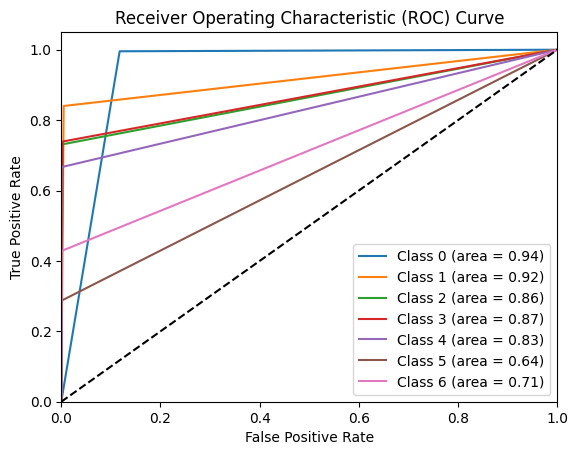

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Assuming true_labels_flat and pred_labels_flat are already defined in the "bert aspect analysis" code

# Binarize the labels for multi-class ROC
true_labels_binarized = label_binarize(true_labels_flat, classes=list(label_map.values()))
pred_labels_binarized = label_binarize(pred_labels_flat, classes=list(label_map.values()))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(label_map)):
    fpr[i], tpr[i], _ = roc_curve(true_labels_binarized[:, i], pred_labels_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure()
for i in range(len(label_map)):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
